In [3]:
import numpy as np
import matplotlib.pyplot as plt
hbar = 0.658119 #ueV/ns
kb = 8.617333262145e-2 #ueV/mk

In [69]:
def sigmoid(x, k):
    return 1 / (1 + np.exp(-k*x))

def relaxation_rate(omega, tun, omega_max, T, power = 0, gamma0 = None):
    '''
    tun: tunneling coupling in ueV 
    gamma0: relaxation rate at epsilon = 0. If None, it is calculated as (tun/10)**2*0.1 (GHz)
    omega_max: maximum frequency in ueV. Cut-off frequency typically meV = 1000ueV
    T: temperature in mK
    power: power law for the frequency dependence of the relaxation rate. Default is 0. Phonons would be 3, 1/f noise -1. 
    '''
    if gamma0 is None:
        gamma0 = (tun/40)**2*0.1  # Wang et al. Phys. Rev. Lett. 111, 046801 (2013) has gamma ~ 0.1 GHz at tun ~ 40ueV in Si
    return gamma0 * (omega/tun)**power * np.exp(-np.abs(omega)/omega_max)*sigmoid(omega, 1/(kb*T))

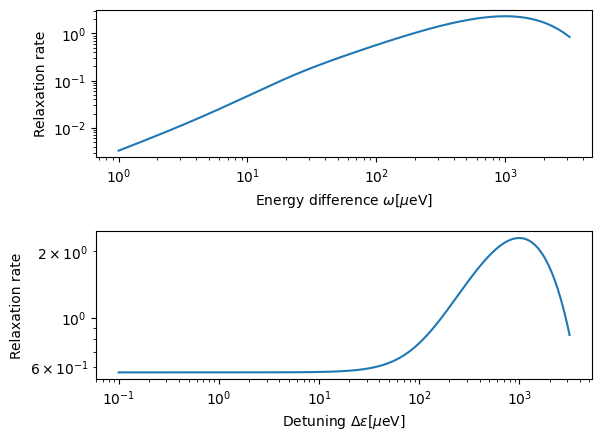

In [74]:
fig, ax = plt.subplots(2,1)
plt.subplots_adjust(hspace=0.5)
omega = np.logspace(0,3.5, 1001)
gamma0 = 1 #GHz
tun = 100
omega_max = 1000
T = 100
alpha = 1
ax[0].plot(omega, relaxation_rate(omega, tun, omega_max, T, alpha))
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("Energy difference $\omega [\mu$eV]")
ax[0].set_ylabel("Relaxation rate")

eps = np.logspace(-1,3.5,1001)
om = np.sqrt(eps**2 + tun**2)
ax[1].plot(eps, relaxation_rate(om, tun, omega_max, T, alpha))
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Detuning $\Delta \epsilon [\mu$eV]")
ax[1].set_ylabel("Relaxation rate")
plt.show()


